# Assignment 3: Probabilistic ML & Time Series I


## Problem 3.1: Bayesian Linear Regression


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 209 seconds.


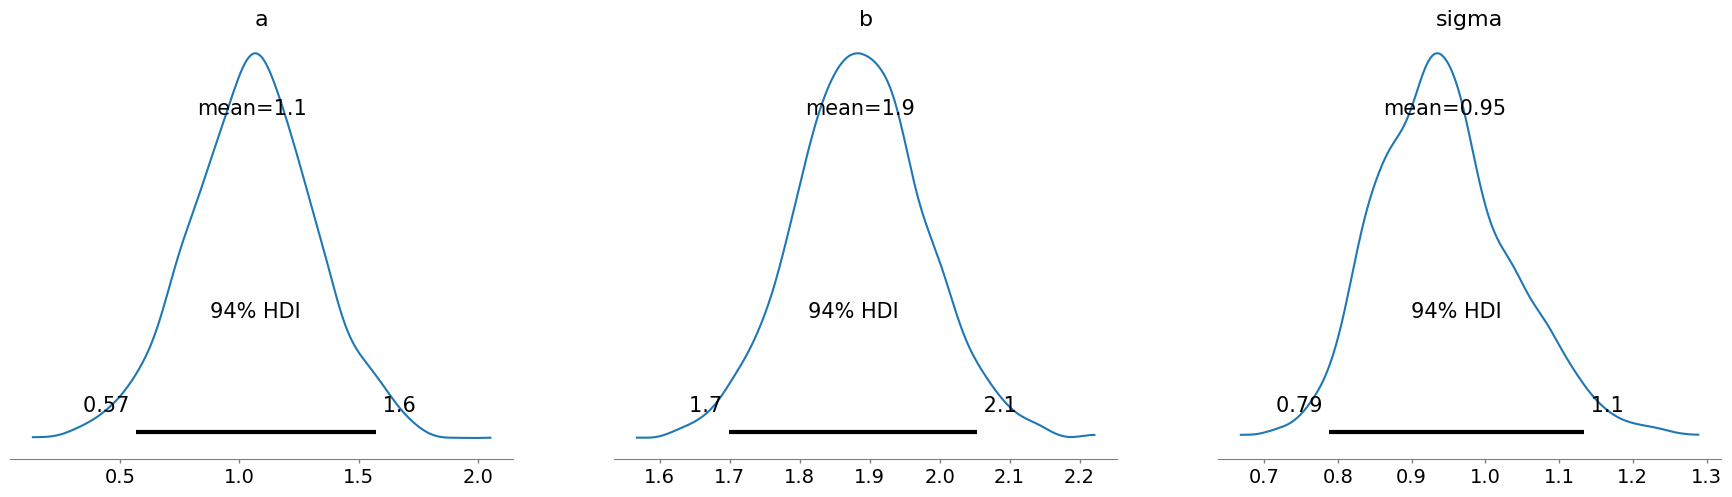

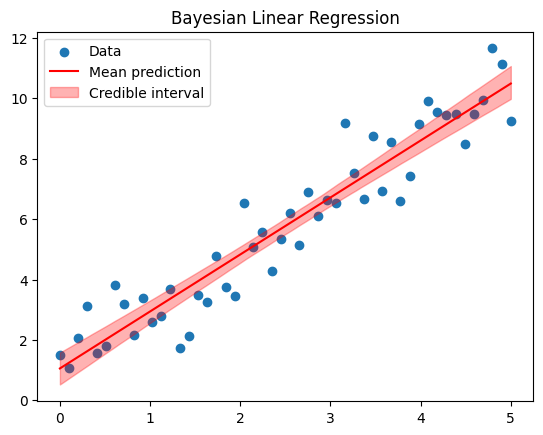

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 5, 50)
y = 1 + 2*X + np.random.normal(0, 1, size=50)

# Bayesian model
with pm.Model() as model:
    a = pm.Normal("a", mu=0, sigma=10)
    b = pm.Normal("b", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = a + b * X

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(500, tune=500, return_inferencedata=True)

# 🔹 Posterior plots
az.plot_posterior(trace)
plt.show()

# 🔹 Extract samples
a_samples = trace.posterior["a"].values.flatten()
b_samples = trace.posterior["b"].values.flatten()

# 🔹 Predictions
X_new = np.linspace(0, 5, 100)
y_preds = np.array([a + b * X_new for a, b in zip(a_samples, b_samples)])

y_mean = y_preds.mean(axis=0)
y_lower = np.percentile(y_preds, 2.5, axis=0)
y_upper = np.percentile(y_preds, 97.5, axis=0)

# 🔹 Final visualization
plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(X_new, y_mean, color="red", label="Mean prediction")
plt.fill_between(X_new, y_lower, y_upper, color="red", alpha=0.3, label="Credible interval")

plt.legend()
plt.title("Bayesian Linear Regression")
plt.show()

### Bayesian Linear Regression Analysis



The model estimates probability distributions for parameters instead of single values. The posterior plots show uncertainty in slope and intercept. The regression plot includes a credible interval, which represents uncertainty in predictions. This makes Bayesian regression more informative than standard regression.


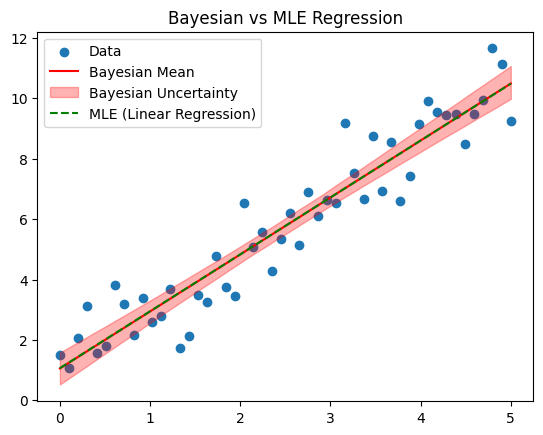

In [9]:
from sklearn.linear_model import LinearRegression

# Fit MLE model
X_reshaped = X.reshape(-1, 1)
mle_model = LinearRegression()
mle_model.fit(X_reshaped, y)

# MLE predictions
y_mle = mle_model.predict(X_new.reshape(-1,1))

# Plot comparison
plt.figure()
plt.scatter(X, y, label="Data")

# Bayesian
plt.plot(X_new, y_mean, color="red", label="Bayesian Mean")
plt.fill_between(X_new, y_lower, y_upper, color="red", alpha=0.3, label="Bayesian Uncertainty")

# MLE
plt.plot(X_new, y_mle, color="green", linestyle="--", label="MLE (Linear Regression)")

plt.legend()
plt.title("Bayesian vs MLE Regression")
plt.show()

### Comparison with Maximum Likelihood Estimation



The MLE model provides a single best-fit line without uncertainty. In contrast, Bayesian regression provides a distribution over parameters and includes credible intervals. This allows better understanding of uncertainty in predictions, making Bayesian methods more informative.

## Problem 3.2: Gaussian Process Regression

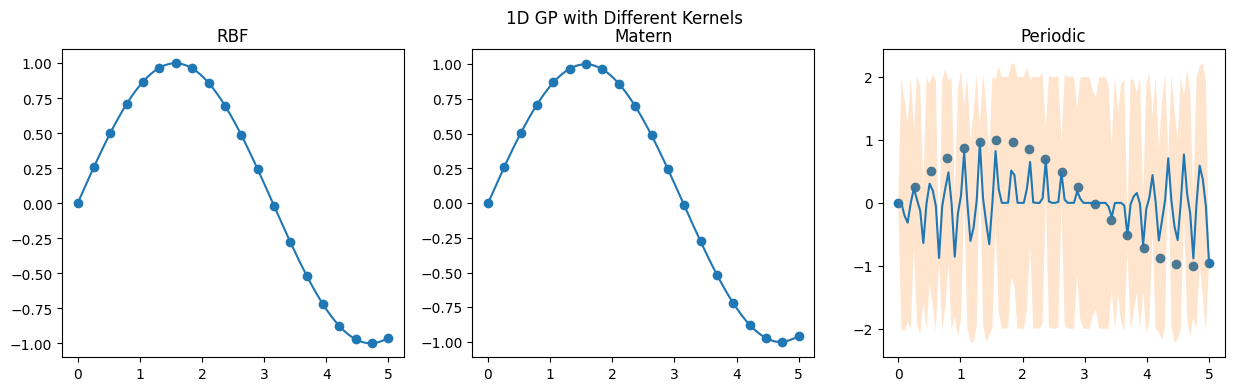

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


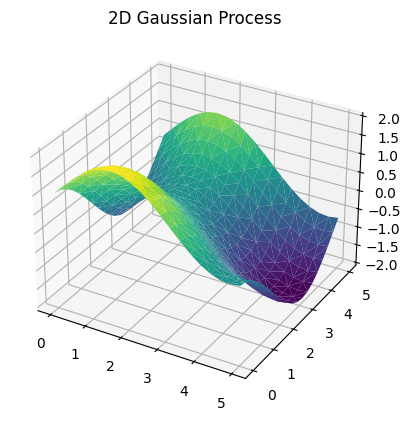

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


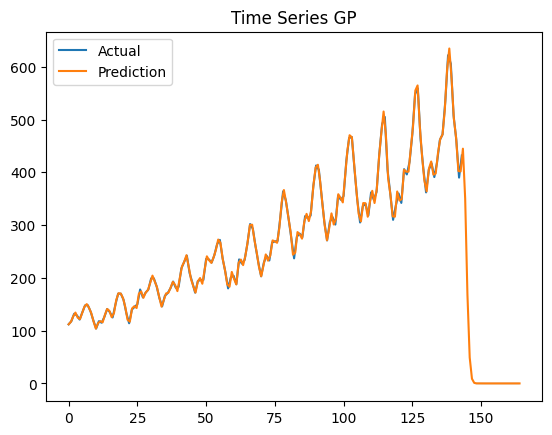

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared
from mpl_toolkits.mplot3d import Axes3D

# =========================
# 1D DATA
# =========================
np.random.seed(42)
X = np.atleast_2d(np.linspace(0, 5, 20)).T
y = np.sin(X).ravel()

X_test = np.linspace(0, 5, 100).reshape(-1,1)

# =========================
# KERNEL COMPARISON
# =========================
kernels = {
    "RBF": RBF(),
    "Matern": Matern(),
    "Periodic": ExpSineSquared()
}

plt.figure(figsize=(15,4))

for i, (name, kernel) in enumerate(kernels.items()):
    gp = GaussianProcessRegressor(kernel=kernel)
    gp.fit(X, y)
    y_pred, std = gp.predict(X_test, return_std=True)

    plt.subplot(1,3,i+1)
    plt.scatter(X, y)
    plt.plot(X_test, y_pred)
    plt.fill_between(X_test.ravel(), y_pred-2*std, y_pred+2*std, alpha=0.2)
    plt.title(name)

plt.suptitle("1D GP with Different Kernels")
plt.show()

# =========================
# 2D DATA
# =========================
x1 = np.linspace(0, 5, 20)
x2 = np.linspace(0, 5, 20)
X1, X2 = np.meshgrid(x1, x2)

X_2d = np.column_stack([X1.ravel(), X2.ravel()])
y_2d = np.sin(X1).ravel() + np.cos(X2).ravel()

gp_2d = GaussianProcessRegressor(kernel=RBF())
gp_2d.fit(X_2d, y_2d)

y_pred_2d = gp_2d.predict(X_2d)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X_2d[:,0], X_2d[:,1], y_pred_2d, cmap='viridis')
plt.title("2D Gaussian Process")
plt.show()

# =========================
# TIME SERIES (AIRLINE DATA)
# =========================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

data['t'] = np.arange(len(data))

X_ts = data[['t']]
y_ts = data['Passengers']

gp_ts = GaussianProcessRegressor(kernel=RBF())
gp_ts.fit(X_ts, y_ts)

X_future = np.linspace(0, len(data)+20, 200).reshape(-1,1)
y_pred_ts, std_ts = gp_ts.predict(X_future, return_std=True)

plt.figure()
plt.plot(X_ts, y_ts, label="Actual")
plt.plot(X_future, y_pred_ts, label="Prediction")
plt.fill_between(X_future.ravel(), y_pred_ts-2*std_ts, y_pred_ts+2*std_ts, alpha=0.2)
plt.title("Time Series GP")
plt.legend()
plt.show()

### Gaussian Process Regression Analysis


## Problem 3.3 ARIMA Modeling

In [44]:
import yfinance as yf
import pandas as pd

# Stock: Google
ticker = "GOOG"

data = yf.download(ticker, start="2023-01-01", end="2026-04-15")
data = data[['Close']].dropna()

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,GOOG
Date,
2023-01-03,88.969566
2023-01-04,87.987633
2023-01-05,86.063416
2023-01-06,87.442108
2023-01-09,88.076897


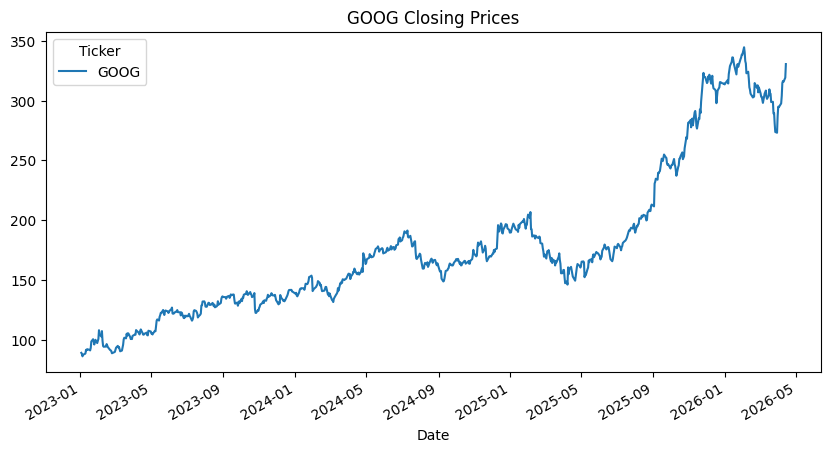

In [45]:
import matplotlib.pyplot as plt

data['Close'].plot(title=f"{ticker} Closing Prices", figsize=(10,5))
plt.show()

#### Check stationarity (ADF test)

In [46]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.5023175250152426
p-value: 0.9849433656567479


In [47]:
data['Diff'] = data['Close'].diff()
data = data.dropna()

result = adfuller(data['Diff'].dropna())
print("ADF Statistic (Differenced):", result[0])
print("p-value:", result[1])

ADF Statistic (Differenced): -27.227384845852537
p-value: 0.0


#### ACF/PACF plots

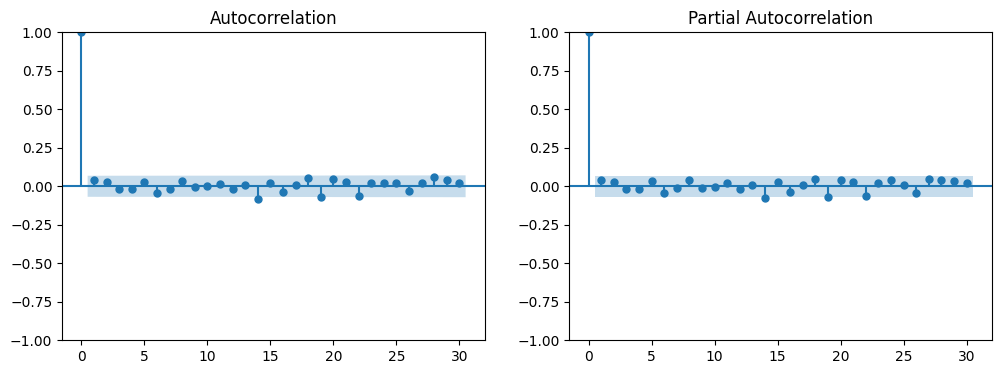

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(data['Diff'].dropna(), ax=axes[0])
plot_pacf(data['Diff'].dropna(), ax=axes[1])
plt.show()

#### ARIMA Model

In [49]:
split = int(len(data) * 0.8)

train = data['Close'][:split]
test = data['Close'][split:]

In [50]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   GOOG   No. Observations:                  656
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1613.668
Date:                Sun, 19 Apr 2026   AIC                           3229.336
Time:                        21:33:56   BIC                           3233.821
Sample:                             0   HQIC                          3231.075
                                - 656                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         8.0797      0.244     33.102      0.000       7.601       8.558
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):               640.76
Prob(Q):                              0.79   Pr

C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


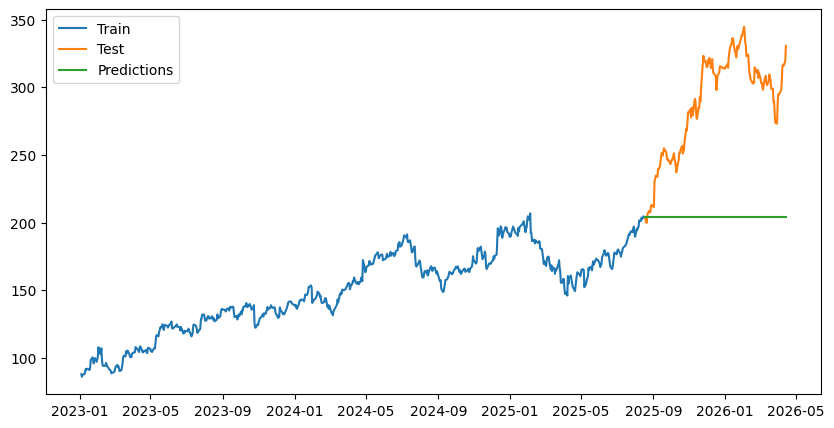

RMSE: 90.72238142841016


In [51]:
# Validation
pred = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred, label="Predictions")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred))
print("RMSE:", rmse)

#### 30-day forecast with confidence intervals

C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


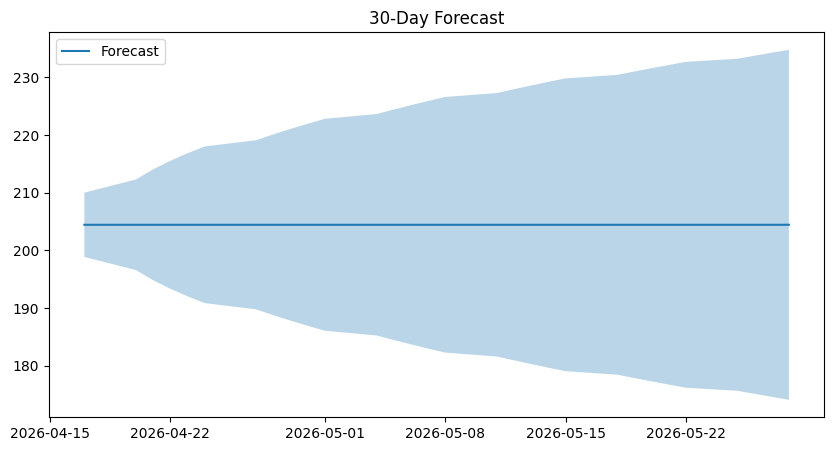

In [32]:
import pandas as pd
from datetime import datetime

# Generate forecast
forecast = model_fit.get_forecast(steps=30)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create date range starting TODAY
today = pd.Timestamp.today().normalize()

future_dates = pd.date_range(start=today, periods=30, freq='B')  # 'B' = business days

# Assign new index
mean_forecast.index = future_dates
conf_int.index = future_dates

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot ONLY forecast
plt.plot(mean_forecast.index, mean_forecast, label="Forecast")

# Confidence interval
plt.fill_between(mean_forecast.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)

plt.title("30-Day Forecast")
plt.legend()
plt.show()

## Problem 3.4 GARCH Volatility Modeling

In [33]:
sp500 = yf.download("^GSPC", start="2022-01-01", end="2024-12-31")
sp500 = sp500[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [34]:
# Compute returns
import numpy as np

sp500['Returns'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
sp500 = sp500.dropna()

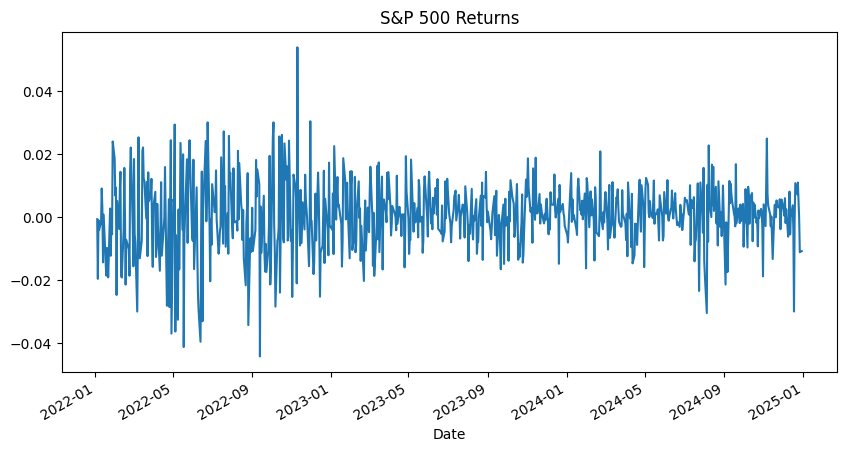

In [35]:
sp500['Returns'].plot(title="S&P 500 Returns", figsize=(10,5))
plt.show()

In [36]:
# Fit GARCH(1,1)
from arch import arch_model

model = arch_model(sp500['Returns']*100, vol='Garch', p=1, q=1)
garch_fit = model.fit(disp='off')

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1066.14
Distribution:                  Normal   AIC:                           2140.29
Method:            Maximum Likelihood   BIC:                           2158.77
                                        No. Observations:                  751
Date:                Fri, Apr 17 2026   Df Residuals:                      750
Time:                        20:39:48   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0661  3.388e-02      1.951  5.110e-02 [-3.16

In [37]:
# Forecast volatility (20 days)
forecast = garch_fit.forecast(horizon=20)

vol_forecast = forecast.variance.iloc[-1] ** 0.5

print(vol_forecast)

h.01    0.944957
h.02    0.945865
h.03    0.946763
h.04    0.947651
h.05    0.948530
h.06    0.949399
h.07    0.950258
h.08    0.951108
h.09    0.951949
h.10    0.952780
h.11    0.953602
h.12    0.954415
h.13    0.955220
h.14    0.956015
h.15    0.956802
h.16    0.957580
h.17    0.958350
h.18    0.959112
h.19    0.959865
h.20    0.960610
Name: 2024-12-30 00:00:00, dtype: float64


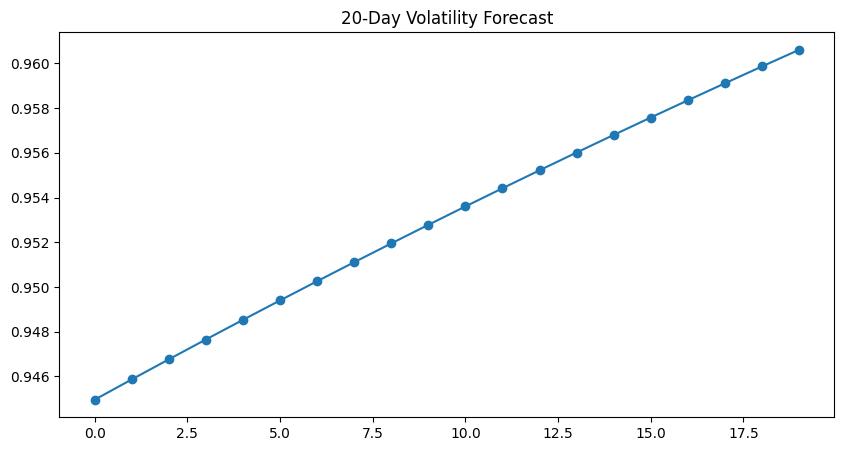

In [38]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(vol_forecast.values, marker='o')
plt.title("20-Day Volatility Forecast")
plt.show()

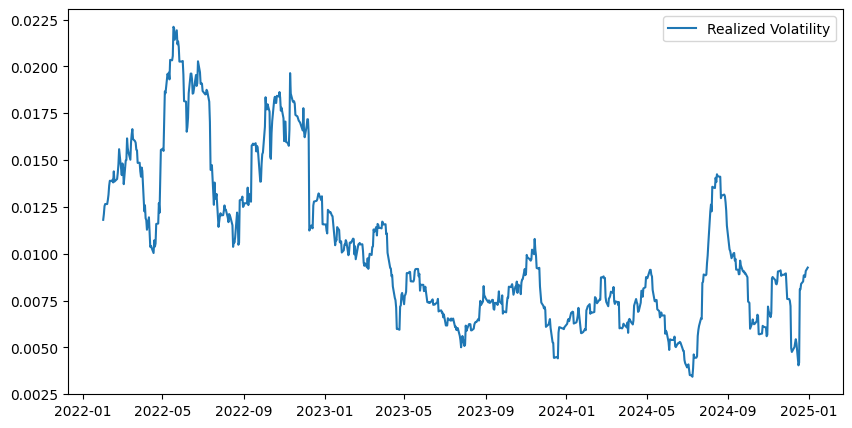

In [39]:
# Validate
# Rolling realized volatility
realized_vol = sp500['Returns'].rolling(window=20).std()

plt.figure(figsize=(10,5))
plt.plot(realized_vol, label="Realized Volatility")
plt.legend()
plt.show()